原训练集样本数: 7767, 过采样后: 17076
测试集准确率: 93.67%

分类报告：
              precision    recall  f1-score   support

           1       0.93      0.98      0.96       496
           2       0.93      0.93      0.93       471
           3       0.97      0.92      0.95       420
           4       0.94      0.90      0.92       508
           5       0.91      0.94      0.93       556
           6       1.00      1.00      1.00       545
           7       0.83      0.83      0.83        23
           8       0.83      1.00      0.91        10
           9       0.74      0.78      0.76        32
          10       0.77      0.68      0.72        25
          11       0.77      0.73      0.75        49
          12       0.69      0.74      0.71        27

    accuracy                           0.94      3162
   macro avg       0.86      0.87      0.86      3162
weighted avg       0.94      0.94      0.94      3162



C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra

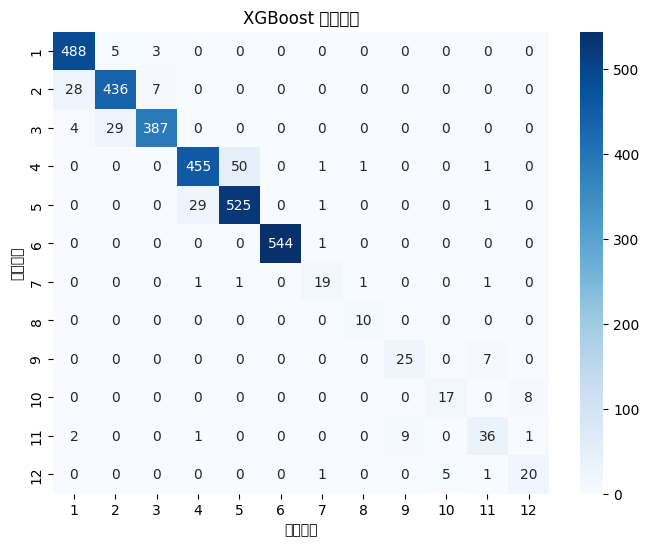

In [28]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE  # 需要安装 imbalanced-learn: pip install imbalanced-learn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# --- 前面部分：加载数据，与之前相同 ---
X_train = np.loadtxt("Train/X_train.txt")
y_train = np.loadtxt("Train/y_train.txt", dtype=int)
X_test  = np.loadtxt("Test/X_test.txt")
y_test  = np.loadtxt("Test/y_test.txt",dtype=int)

# 标签编码从 0 到 num_classes-1
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# ============================================
# 1. 在训练集上做 SMOTE 过采样 (合成少数类过采样技术)
# ============================================
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train_enc)
print(f"原训练集样本数: {X_train.shape[0]}, 过采样后: {X_resampled.shape[0]}")

# ============================================
# 2. 用过采样后的数据构建 DMatrix
# ============================================
dtrain = xgb.DMatrix(X_resampled, label=y_resampled)
dtest  = xgb.DMatrix(X_test,    label=y_test_enc)

# ============================================
# 3. 定义和训练 XGBoost 多分类模型
# ============================================
params = {
    'objective': 'multi:softmax',
    'num_class': len(le.classes_),   # 类别数
    'eval_metric': 'mlogloss',
    'max_depth': 5,
    'eta': 0.3,
    'subsample': 1.0,
    'colsample_bytree': 0.6,

}
num_round = 1000
bst = xgb.train(params, dtrain, num_round)

# ============================================
# 4. 在测试集上做预测并评估
# ============================================
y_pred_enc = bst.predict(dtest).astype(int)
y_pred      = le.inverse_transform(y_pred_enc)

acc = accuracy_score(y_test, y_pred)
print(f"测试集准确率: {acc*100:.2f}%")

print("\n分类报告：")
# 假设 y_test, y_pred 都是原始标签（整数）
target_str = [str(c) for c in le.classes_]

print(classification_report(
    y_test,
    y_pred,
    target_names=target_str
))
# 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("预测类别")
plt.ylabel("真实类别")
plt.title("XGBoost 混淆矩阵")
plt.show()


In [ ]:
# bst 是基于 X_resampled、y_resampled 训练得到的
y_train_resampled_pred = bst.predict(dtrain)                  # 预测增广后训练集
train_acc_resampled = accuracy_score(y_resampled, y_train_resampled_pred)
print(f"Train Acc on SMOTE data: {train_acc_resampled*100:.2f}%")


Train Acc on SMOTE data: 100.00%


In [5]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

model = XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    max_depth=6, eta=0.3,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss'
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    model, X_resampled, y_resampled,
    cv=cv, scoring='accuracy'
)
print("5折CV 准确率：", scores, " 平均：", scores.mean())


C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [14:24:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [14:25:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [14:25:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } 

5折CV 准确率： [0.99677986 0.99560761 0.99531479 0.99677892 0.99619327]  平均： 0.9961348884416115


In [9]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# 1. 准备数据
X = np.loadtxt("Train/X_train.txt")
y = np.loadtxt("Train/y_train.txt", dtype=int)
le = LabelEncoder()
y_enc = le.fit_transform(y)

# 2. 一次性划分：80% 训练，20% 验证（分层保证比例）
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)

# 3. 构建 Pipeline（先 SMOTE，再 XGB）
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        use_label_encoder=False,
        eval_metric="mlogloss",
        n_jobs=-1
    ))
])

# 4. 定义随机搜索空间（注意 Pipeline 中参数名前要加 "clf__"）
param_dist = {
    "clf__n_estimators":      [50, 100, 200, 300],
    "clf__learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth":         [3, 5, 7, 9],
    "clf__min_child_weight":  [1, 3, 5],
    "clf__subsample":         [0.6, 0.8, 1.0],
    "clf__colsample_bytree":  [0.6, 0.8, 1.0],
    "clf__gamma":             [0, 0.1, 0.2, 0.5],
    "clf__reg_alpha":         [0, 0.01, 0.1],
    "clf__reg_lambda":        [1, 1.5, 2]
}

# 5. 随机采样 50 组参数
param_list = list(ParameterSampler(param_dist, n_iter=50, random_state=42))

best_score = 0
best_params = None

# 6. 循环训练评估
for i, params in enumerate(param_list, 1):
    # 更新管道参数
    pipeline.set_params(**params)
    # 只在训练子集上做 SMOTE+fit
    pipeline.fit(X_tr, y_tr)
    # 验证集上预测
    y_pred = pipeline.predict(X_val)
    # 用 macro-F1 评估少数类表现
    score = f1_score(y_val, y_pred, average="macro")
    print(f"组合 {i:02d} / 50 — F1_macro: {score:.4f}")
    if score > best_score:
        best_score, best_params = score, params

print("\n搜索结束")
print("最佳 F1_macro:", best_score)
print("最佳参数:", best_params)


C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [15:05:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


组合 01 / 50 — F1_macro: 0.8628


C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [15:05:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


组合 02 / 50 — F1_macro: 0.8630


C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [15:06:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

组合 48 / 50 — F1_macro: 0.8459


C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [15:35:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


组合 49 / 50 — F1_macro: 0.8498


C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [15:35:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


组合 50 / 50 — F1_macro: 0.8638

搜索结束
最佳 F1_macro: 0.885896172551095
最佳参数: {'clf__subsample': 1.0, 'clf__reg_lambda': 1, 'clf__reg_alpha': 0.01, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__gamma': 0, 'clf__colsample_bytree': 0.6}


C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [15:36:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


▶ 测试集准确率: 92.66%

▶ 测试集分类报告：
              precision    recall  f1-score   support

           1       0.93      0.97      0.95       496
           2       0.90      0.93      0.92       471
           3       0.98      0.90      0.94       420
           4       0.92      0.88      0.90       508
           5       0.89      0.93      0.91       556
           6       1.00      1.00      1.00       545
           7       0.91      0.87      0.89        23
           8       0.83      1.00      0.91        10
           9       0.76      0.81      0.79        32
          10       0.68      0.60      0.64        25
          11       0.82      0.76      0.79        49
          12       0.62      0.67      0.64        27

    accuracy                           0.93      3162
   macro avg       0.85      0.86      0.86      3162
weighted avg       0.93      0.93      0.93      3162



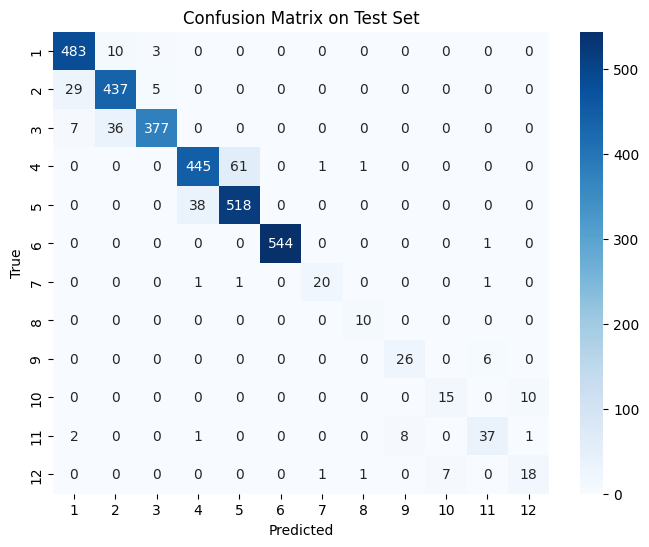

In [10]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 1. 重新加载全量训练集和测试集
X_train = np.loadtxt("Train/X_train.txt")
y_train = np.loadtxt("Train/y_train.txt", dtype=int)
X_test  = np.loadtxt("Test/X_test.txt")
y_test  = np.loadtxt("Test/y_test.txt", dtype=int)

# 2. 标签编码
le = LabelEncoder().fit(np.concatenate([y_train, y_test]))
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

# 3. 构建 Pipeline，并注入最佳超参数
best_params = {
    "clf__subsample":       1.0,
    "clf__reg_lambda":      1,
    "clf__reg_alpha":       0.01,
    "clf__n_estimators":    200,
    "clf__min_child_weight":1,
    "clf__max_depth":       5,
    "clf__learning_rate":   0.05,
    "clf__gamma":           0,
    "clf__colsample_bytree":0.6
}

pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        use_label_encoder=False,
        eval_metric="mlogloss",
        n_jobs=-1
    ))
])
pipeline.set_params(**best_params)

# 4. 在全量训练集上训练
pipeline.fit(X_train, y_train_enc)

# 5. 在测试集上预测并评估
y_pred_enc = pipeline.predict(X_test)
y_pred     = le.inverse_transform(y_pred_enc)

acc = accuracy_score(y_test, y_pred)
print(f"▶ 测试集准确率: {acc*100:.2f}%\n")

print("▶ 测试集分类报告：")
print(classification_report(
    y_test,
    y_pred,
    target_names=[str(c) for c in le.classes_]
))

# 6. 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.show()


In [14]:
import numpy as np
import optuna
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 1. 加载数据
X = np.loadtxt("Train/X_train.txt")
y = np.loadtxt("Train/y_train.txt", dtype=int)
le = LabelEncoder().fit(y)
y_enc = le.transform(y)

# 2. 把我们在随机搜索里找到的最佳超参复制过来
best_params = {
    "objective":      "multi:softprob",
    "num_class":      len(le.classes_),
    "use_label_encoder": False,
    "eval_metric":    "mlogloss",
    "n_jobs":         -1,
    "subsample":      1.0,
    "reg_lambda":     1,
    "reg_alpha":      0.01,
    "n_estimators":   200,
    "min_child_weight": 1,
    "max_depth":      5,
    "learning_rate":  0.05,
    "gamma":          0,
    "colsample_bytree": 0.6
}

# 3. 定义 Optuna 目标函数
def objective(trial):
    # 在 [10, 全量特征数] 之间搜索最优 k
    k = trial.suggest_int("k", 10, X.shape[1], step=10)
    
    # 构建包含特征选择、SMOTE、XGB 的 Pipeline
    clf = XGBClassifier(**best_params)
    pipeline = Pipeline([
        ("selector", SelectKBest(f_classif, k=k)),
        ("smote", SMOTE(random_state=42)),
        ("clf", clf)
    ])
    
    # 分层 3 折 CV，评价 macro‑F1
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline, X, y_enc,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )
    # 返回平均分，让 Optuna 最大化它
    return scores.mean()

# 4. 创建并运行 Study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, timeout=600)

# 5. 输出最优结果
print("最佳特征数 k =", study.best_params["k"])
print("对应 CV F1_macro =", study.best_value)


[I 2025-04-17 15:45:00,702] A new study created in memory with name: no-name-2bc7b615-463c-4e32-b486-7036510e6d84
C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\distributions.py:699: UserWarning: The distribution is specified by [10, 561] and step=10, but the range is not divisible by `step`. It will be replaced by [10, 560].
  warnings.warn(
[I 2025-04-17 15:45:09,155] Trial 0 finished with value: 0.762303007837054 and parameters: {'k': 30}. Best is trial 0 with value: 0.762303007837054.
C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\distributions.py:699: UserWarning: The distribution is specified by [10, 561] and step=10, but the range is not divisible by `step`. It will be replaced by [10, 560].
  warnings.warn(
[I 2025-04-17 15:46:14,291] Trial 1 finished with value: 0.8758789228142779 a

最佳特征数 k = 540
对应 CV F1_macro = 0.8810558132351313


C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [15:56:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


测试集准确率: 92.19%

测试集分类报告：
              precision    recall  f1-score   support

           1       0.91      0.96      0.93       496
           2       0.90      0.91      0.91       471
           3       0.97      0.90      0.93       420
           4       0.92      0.87      0.90       508
           5       0.89      0.94      0.91       556
           6       1.00      1.00      1.00       545
           7       0.95      0.87      0.91        23
           8       0.71      1.00      0.83        10
           9       0.78      0.78      0.78        32
          10       0.64      0.64      0.64        25
          11       0.80      0.76      0.78        49
          12       0.64      0.59      0.62        27

    accuracy                           0.92      3162
   macro avg       0.84      0.85      0.84      3162
weighted avg       0.92      0.92      0.92      3162



C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lisiq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra

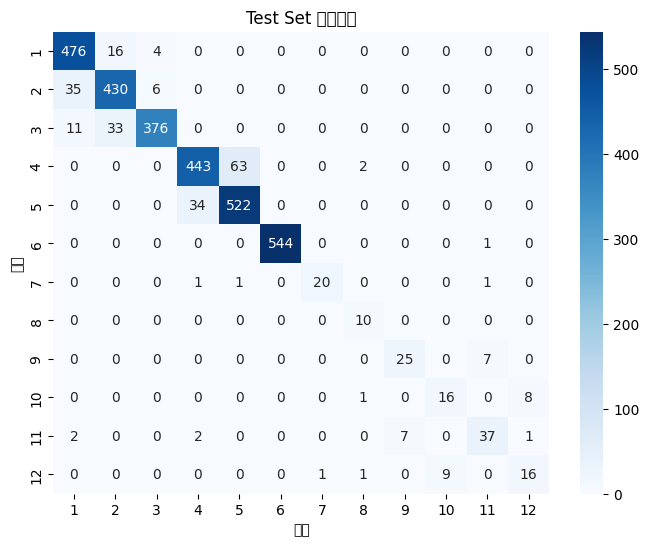

In [15]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 重新加载全量训练集与测试集
X_train = np.loadtxt("Train/X_train.txt")
y_train = np.loadtxt("Train/y_train.txt", dtype=int)
X_test  = np.loadtxt("Test/X_test.txt")
y_test  = np.loadtxt("Test/y_test.txt", dtype=int)

# 2. 标签编码
le = LabelEncoder().fit(np.concatenate([y_train, y_test]))
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

# 3. 构建最终 Pipeline：SelectKBest(k=540) → SMOTE → XGBClassifier(最佳超参)
selector = SelectKBest(f_classif, k=540)
smote    = SMOTE(random_state=42)
clf      = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_jobs=-1,
    # 下方填入你之前搜索到的最佳超参
    subsample=1.0,
    reg_lambda=1,
    reg_alpha=0.01,
    n_estimators=200,
    min_child_weight=1,
    max_depth=5,
    learning_rate=0.05,
    gamma=0,
    colsample_bytree=0.6
)

pipeline = Pipeline([
    ("selector", selector),
    ("smote",    smote),
    ("clf",      clf)
])

# 4. 在全量训练集上训练
pipeline.fit(X_train, y_train_enc)

# 5. 在测试集上预测并评估
y_pred_enc = pipeline.predict(X_test)
y_pred     = le.inverse_transform(y_pred_enc)

acc = accuracy_score(y_test, y_pred)
print(f"测试集准确率: {acc*100:.2f}%\n")

print("测试集分类报告：")
print(classification_report(
    y_test, y_pred,
    target_names=[str(c) for c in le.classes_]
))

# 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("预测")
plt.ylabel("真实")
plt.title("Test Set 混淆矩阵")
plt.show()
